# Modeling

This notebook covers the complete machine learning pipeline, including:

* Data Preprocessing
* Model selection
* Model experimentation and optimizing
* Saving the final model pipeline

----

## Data Preprocessing

To ensure reproducibility and cleaner experimentation, all preprocessing logic is implemented as reusable functions inside:

    ./src/preprocessing.py

The preprocessing pipeline includes:

* Splitting continuous target variable into three classes
* Encoding categorical features
* Train\test splitting

----

## Model Selection

Several models are trained to select one for future optimizing:

* Logistic Regression
* SVM
* XGBoost
* CatBoost
* Random Forest


# Data Preprocessing

In [1]:
import pandas as pd
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)

sys.path.append(str(Path("..").resolve()))

DATA_DIR = Path("../dataset/student")

csv_files = list(DATA_DIR.glob("*.csv"))

csv_files

[WindowsPath('../dataset/student/student-mat.csv'),
 WindowsPath('../dataset/student/student-por.csv')]

In [2]:
# Choosing portuguese student dataset
df = pd.read_csv(csv_files[1], sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


In [3]:
import src.preprocessing as preprocessing

df = preprocessing.create_class_target_variable(df)
df = preprocessing.delete_continuous_targets(df)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   school      649 non-null    str     
 1   sex         649 non-null    str     
 2   age         649 non-null    int64   
 3   address     649 non-null    str     
 4   famsize     649 non-null    str     
 5   Pstatus     649 non-null    str     
 6   Medu        649 non-null    int64   
 7   Fedu        649 non-null    int64   
 8   Mjob        649 non-null    str     
 9   Fjob        649 non-null    str     
 10  reason      649 non-null    str     
 11  guardian    649 non-null    str     
 12  traveltime  649 non-null    int64   
 13  studytime   649 non-null    int64   
 14  failures    649 non-null    int64   
 15  schoolsup   649 non-null    str     
 16  famsup      649 non-null    str     
 17  paid        649 non-null    str     
 18  activities  649 non-null    str     
 19  nursery     649 non

In [4]:
from sklearn.model_selection import train_test_split

X, y = preprocessing.split_X_y(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, y_train.shape

((519, 30), (519,))

Creating different pipelines for different models

In [5]:
cat_features = X.select_dtypes(include=['string', 'object']).columns
num_features = X.select_dtypes(include=['int']).columns

preprocessor_lin = preprocessing.create_preprocessor(
    categorical_features=cat_features,
    numerical_features=num_features,
    scale_numeric=True,
    encode_categorical="onehot"
)

preprocessor_tree = preprocessing.create_preprocessor(
    categorical_features=cat_features,
    numerical_features=num_features,
    scale_numeric=False,
    encode_categorical="onehot"
)

preprocessor_catboost = preprocessing.create_preprocessor(
    categorical_features=cat_features,
    numerical_features=num_features,
    scale_numeric=False,
    encode_categorical="passthrough"
)

# Model Selection

This section is dedicated to identifying the best baseline model for further optimization and tuning.

The following models will be evaluated:

* LogisticRegression
* RandomForest
* SVC
* XGBoost
* CatBoost

XGBoost and CatBoost use separate pipelines due to their model-specific preprocessing requirements and training strategies.

The remaining scikit-learn models are combined into a single GridSearch pipeline.

At the end of this section all models will be compared using the selected evaluation metrics.

Different estimator types require different processing strategies. To simplify experimentation, a custom preprocessing utility was implemented in ./src/preprocessing.py, allowing flexible configuration of feature transformation.

----

## Evalution metric.
The Student Performance Dataset (Portuguese language version) conatins 649 rows.

After transforming continuous target variable G3 into a multiclass target (G3_class), a strong class imbalance appeared.

The key business question becomes:

Should the model prioritize overall predictive performance of majority classes?
Or should it prioritize detecting low-performance students despite the class imbalance?
The answer directly affects the choice of evaluation metrics.

----

## Important Trade-Off
There is an important trade-off to consider:

* Optimizing for minority-class detection may reduce overall accuracy and increase false positives.
* Optimizing for majority-class performance may cause the model to ignore the minority class entirely.

The primary optimization objective is minority-class recall.

Missing low-performance students is considered more costly than incorrectly flagging average-performing students.

## Scikit-learn models

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV

baseline_pipeline = Pipeline([
    ("preprocessor", None),
    ("model", None)
])

param_grid = [
    # ========================= Logistic Regresssion =========================
    {
        "model": [LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")],
        "preprocessor": [preprocessor_lin],
        "model__C": [0.01, 0.1, 1, 10],
        "model__l1_ratio": [0],
        "model__solver": ["newton-cholesky", "lbfgs"]
    },

    # ========================= SVM =========================
    {
        "model": [SVC(random_state=42, class_weight="balanced", probability=True)],
        "preprocessor": [preprocessor_lin],
        "model__C": [0.01, 0.1, 1, 10],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    },

     # ========================= Random Forest =========================
    {
        "model": [RandomForestClassifier(random_state=42, class_weight="balanced")],
        "preprocessor": [preprocessor_tree],
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [None, 10, 20, 50],
        "model__min_samples_split": [2, 5]
    }
]

cv = StratifiedKFold(random_state=42, shuffle=True, n_splits=3)

baseline_grid = GridSearchCV(
    estimator=baseline_pipeline,
    param_grid=param_grid,
    scoring="recall_macro",
    n_jobs=-1,
    cv=cv
)

baseline_grid.fit(X_train, y_train)

baseline_model = baseline_grid.best_estimator_
baseline_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [7]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import src.modeling as modeling

y_pred = baseline_model.predict(X_test)

baseline_metrics_df = modeling.calc_model_metrics(y_test=y_test, y_pred=y_pred)

baseline_metrics_df

,metric,value
0,precision macro,0.543561
1,recall macro,0.689010
2,f1 macro,0.549800
3,balanced accuracy,0.689010


In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.19      0.75      0.30         4
           1       0.79      0.54      0.64        71
           2       0.65      0.78      0.71        55

    accuracy                           0.65       130
   macro avg       0.54      0.69      0.55       130
weighted avg       0.71      0.65      0.66       130



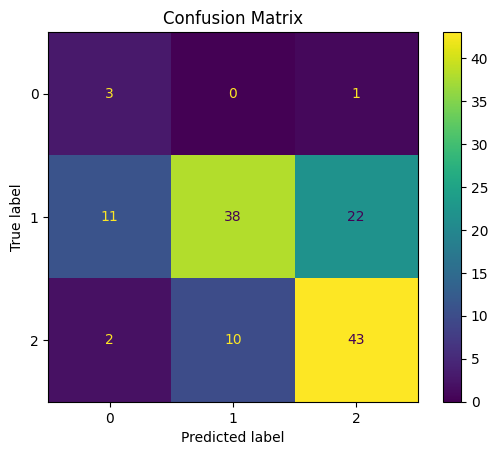

In [9]:
baseline_cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(baseline_cm).plot()

plt.title(f"Confusion Matrix")
plt.show()

## XGBoost

In [10]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

xgboost_pipeline = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", XGBClassifier(
        random_state=42,
        num_class=3,
        objective="multi:softprob",
        eval_metric="mlogloss"
    ))
])

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [3, 5, 7, 9],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0]
}

cv = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

xgb_grid = GridSearchCV(
    estimator=xgboost_pipeline,
    param_grid=param_grid,
    scoring="recall_macro",
    cv=cv,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train, model__sample_weight=sample_weight)
xgb_model = xgb_grid.best_estimator_

xgb_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [11]:
y_pred = xgb_model.predict(X_test)

xgb_metrics_df = modeling.calc_model_metrics(y_test=y_test, y_pred=y_pred)

xgb_metrics_df

,metric,value
0,precision macro,0.582285
1,recall macro,0.652027
2,f1 macro,0.594982
3,balanced accuracy,0.652027


In [12]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.25      0.50      0.33         4
           1       0.83      0.62      0.71        71
           2       0.67      0.84      0.74        55

    accuracy                           0.71       130
   macro avg       0.58      0.65      0.59       130
weighted avg       0.74      0.71      0.71       130



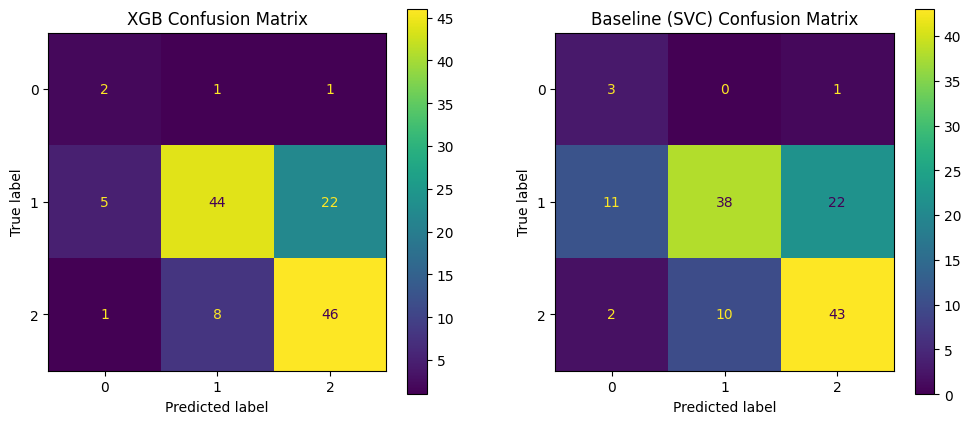

In [13]:
xgb_cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
ConfusionMatrixDisplay(xgb_cm).plot(ax=axes[0])
ConfusionMatrixDisplay(baseline_cm).plot(ax=axes[1])

axes[0].set_title("XGB Confusion Matrix")
axes[1].set_title("Baseline (SVC) Confusion Matrix")
plt.show()

## CatBoost

In [14]:
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weigths = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

weigths

array([10.8125    ,  0.61347518,  0.78280543])

In [15]:
cat_features_idx = [
    X_train.columns.get_loc(col)
    for col in cat_features
]

cat_features_idx

[0, 1, 3, 4, 5, 8, 9, 10, 11, 15, 16, 17, 18, 19, 20, 21, 22]

In [16]:
%%time

from catboost import Pool

train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=cat_features_idx
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=cat_features_idx
)

cat_model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    class_weights=weigths,
    random_state=42,
    logging_level="Silent",
    thread_count=-1
)

param_grid = {
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "iterations": [200, 400],
    "l2_leaf_reg": [1, 3, 5]
}

catboost_grid = cat_model.grid_search(
    param_grid=param_grid,
    X=train_pool,
    cv=3,
    stratified=True,
    verbose=0,
    partition_random_seed=42
)

y_pred = cat_model.predict(X_test)

CPU times: total: 3min 44s
Wall time: 4min 18s


In [17]:
catboost_metric_df = modeling.calc_model_metrics(y_test=y_test, y_pred=y_pred)
catboost_metric_df

,metric,value
0,precision macro,0.667383
1,recall macro,0.669441
2,f1 macro,0.663850
3,balanced accuracy,0.669441


In [18]:
print(classification_report(y_true=y_test, y_pred=y_pred))

              precision    recall  f1-score   support

           0       0.50      0.50      0.50         4
           1       0.83      0.69      0.75        71
           2       0.67      0.82      0.74        55

    accuracy                           0.74       130
   macro avg       0.67      0.67      0.66       130
weighted avg       0.75      0.74      0.74       130



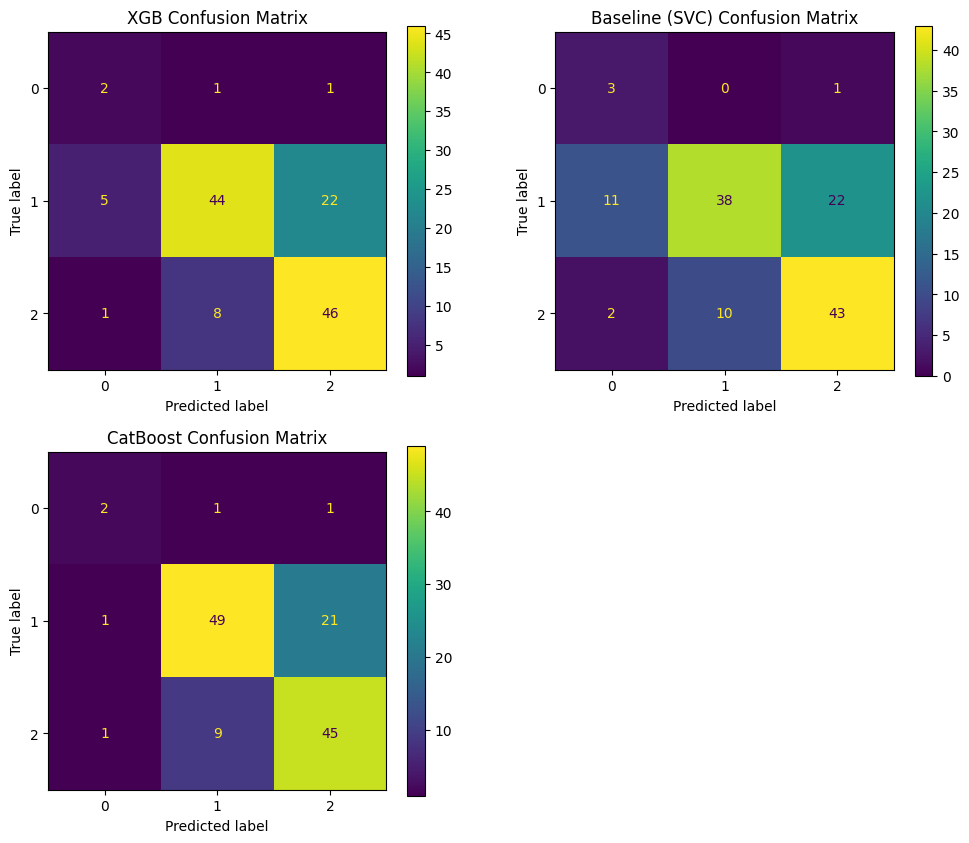

In [19]:
catboost_cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

axes = axes.flatten()

ConfusionMatrixDisplay(xgb_cm).plot(ax=axes[0])
ConfusionMatrixDisplay(baseline_cm).plot(ax=axes[1])
ConfusionMatrixDisplay(catboost_cm).plot(ax=axes[2])

axes[0].set_title("XGB Confusion Matrix")
axes[1].set_title("Baseline (SVC) Confusion Matrix")
axes[2].set_title("CatBoost Confusion Matrix")

fig.delaxes(axes[3])
plt.show()

## Baseline conclusion

1. `SVC` - shows the best recall overall all trained models. However it has 11 False Positives that makes model not perfect.
2. `XGBoost` - shows more stable results overall all of three classes. It provides recall only of 0.50 (compared to 0.75 which was achieved by SVC). XGboost also has less False Positives on minority class
3. `CatBoost` - provides the best overall results on all classes. Unfortunately it's on the same level of recall as XGBoost (0.50) but shows the least False Positives compared to SVC and XGboost.

`CatBoost` is considered to be the main model for future optimizing. The goal is to keep its performance and increase recall for minority class.

# Feature analysis after training

Before experimentation on `CatBoost` is started, is neccessary to observe its weaknesses and possible errors. It helps to adjust and choose the best tuning strategy.

In [20]:
import pandas as pd
from sklearn.inspection import permutation_importance

result = permutation_importance(
    cat_model,
    X_test,
    y_test,
    n_repeats=50,
    random_state=42,
    scoring="recall_macro"
)

importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

importance_df

,feature,importance
2,age,0.096522
29,absences,0.082014
14,failures,0.028977
20,higher,0.020120
8,Mjob,0.015138
0,school,0.013970
6,Medu,0.012864
10,reason,0.011927
7,Fedu,0.011746
13,studytime,0.011604


In [21]:
probs = cat_model.predict_proba(X_test)
y_pred = cat_model.predict(X_test)
confidence = probs.max(axis=1)

round(confidence.mean(), 4)

np.float64(0.6357)

In [22]:
round((confidence[y_pred.flatten() != y_test]).mean(), 4)

np.float64(0.5864)

## Feature Analysis Conclusion

# Experimentation

## Hypothethis 1. Delete noisy \ weak features


In [23]:
selected_features = importance_df[
    importance_df['importance'] > 0
]['feature'].tolist()

X_trained_selected = X_train[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

cat_features_idx_selected = [
    X_trained_selected.columns.get_loc(col)
    for col in selected_features
]

train_pool_selected = Pool(
    data=X_trained_selected,
    label=y_train,
    cat_features=cat_features_idx_selected
)

test_pool_selected = Pool(
    data=X_test_selected,
    label=y_test,
    cat_features=cat_features_idx_selected
)

best_params = catboost_grid["params"]
best_params

{'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 200}

In [24]:
%%time

experimental_cat_model = CatBoostClassifier(
    **best_params,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    class_weights=weigths,
    random_state=42,
    logging_level="Silent",
    thread_count=-1
)

experimental_cat_model.fit(train_pool_selected)

experimental_y_pred = experimental_cat_model.predict(X_test_selected)

CPU times: total: 5.8 s
Wall time: 5.41 s


In [25]:
experimental_metric_df = modeling.calc_model_metrics(y_test=y_test, y_pred=experimental_y_pred)
experimental_metric_df

,metric,value
0,precision macro,0.608498
1,recall macro,0.658088
2,f1 macro,0.618570
3,balanced accuracy,0.658088


In [26]:
print(classification_report(y_pred=experimental_y_pred, y_true=y_test))

              precision    recall  f1-score   support

           0       0.33      0.50      0.40         4
           1       0.83      0.62      0.71        71
           2       0.66      0.85      0.75        55

    accuracy                           0.72       130
   macro avg       0.61      0.66      0.62       130
weighted avg       0.74      0.72      0.72       130



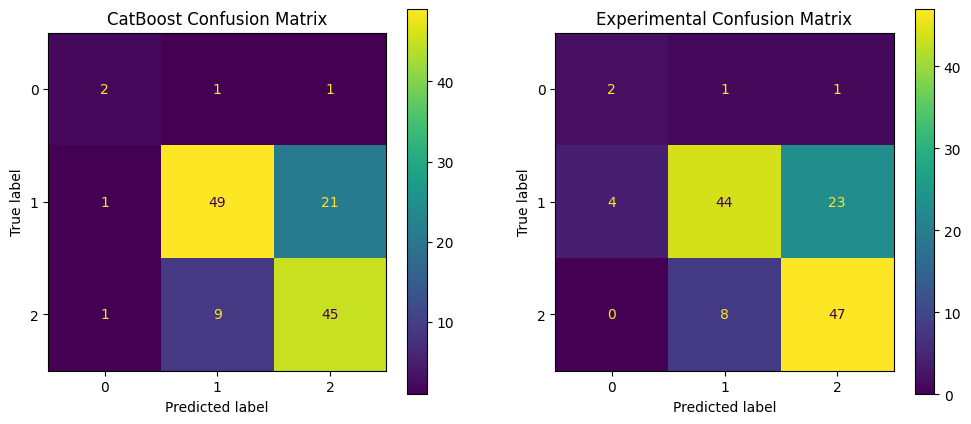

In [27]:
experimental_cm = confusion_matrix(y_true=y_test, y_pred=experimental_y_pred)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

axes = axes.flatten()

ConfusionMatrixDisplay(catboost_cm).plot(ax=axes[0])
ConfusionMatrixDisplay(experimental_cm).plot(ax=axes[1])

axes[0].set_title("CatBoost Confusion Matrix")
axes[1].set_title("Experimental Confusion Matrix")

plt.show()

### Hypothesis 1 Conclusion


## Hypothesis 2. Treshold tuning


In [28]:
from sklearn.metrics import recall_score

probs = cat_model.predict_proba(X_test)

minor_idx = list(cat_model.classes_).index(0)

minor_probs = probs[:, minor_idx]

thresholds = np.arange(0.1, 0.5, 0.01)

results = []

for t in thresholds:
    y_pred = probs.argmax(axis=1)

    y_pred[minor_probs > t] = 0

    score = recall_score(y_test, y_pred, average="macro")

    results.append((t, score))

best_t, best_score = max(results, key=lambda x: x[1])

print(best_t, best_score)

0.21999999999999995 0.7293000426803244


In [29]:
from src.modeling import find_threshold

probs = cat_model.predict_proba(X_test)

minor_idx = list(cat_model.classes_).index(0)

best_t, best_score = find_threshold(
    probs=probs,
    class_idx=minor_idx,
    y_true=y_test,
    metric=recall_score
)

best_t, best_score

(np.float64(0.21999999999999995), 0.7293000426803244)

In [30]:
probs = cat_model.predict_proba(X_test)

minor_idx = list(cat_model.classes_).index(0)

minor_probs = probs[:, minor_idx]

y_pred_final = probs.argmax(axis=1)

y_pred_final[minor_probs > best_t] = 0

print(classification_report(y_true=y_test, y_pred=y_pred_final))

              precision    recall  f1-score   support

           0       0.27      0.75      0.40         4
           1       0.85      0.62      0.72        71
           2       0.67      0.82      0.74        55

    accuracy                           0.71       130
   macro avg       0.60      0.73      0.62       130
weighted avg       0.75      0.71      0.72       130



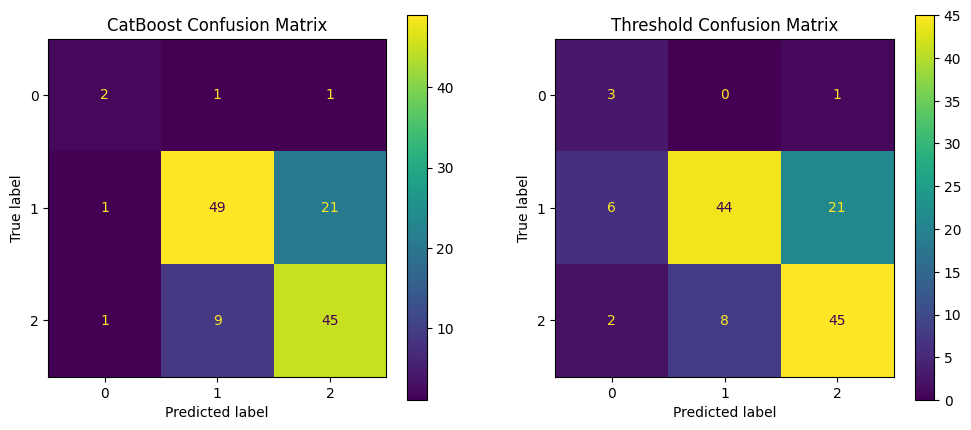

In [31]:
threshold_cm = confusion_matrix(y_true=y_test, y_pred=y_pred_final)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

axes = axes.flatten()

ConfusionMatrixDisplay(catboost_cm).plot(ax=axes[0])
ConfusionMatrixDisplay(threshold_cm).plot(ax=axes[1])

axes[0].set_title("CatBoost Confusion Matrix")
axes[1].set_title("Threshold Confusion Matrix")

plt.show()

### Hypothesis 2 Conclusion